### Comparing Weight-Initialization Methods for Imbalanced DoS Attack Classification

> An Explainable MLP Study with Weighted Cross-Entropy, Model Checkpointing, and Accuracy Confidence Intervals

This notebook conducts a controlled comparison of weight-initialization strategies for a multiclass network-flow classifier built with a Multi-Layer Perceptron (MLP). It extends the earlier study in five important ways:

1. it compares a framework-default baseline against several explicit initialization methods;
2. it retains every class, including the class with the fewest samples;
3. it handles class imbalance using training-only weighted cross-entropy;
4. it trains each model for up to 100 epochs with validation-based checkpointing and optional early stopping;
5. it reports a 95% Wilson confidence interval for test accuracy and explains model decisions using Integrated Gradients.

> **Terminology note.** The reference notebook uses `Wednesday-workingHours.pcap_ISCX.csv` from CIC-IDS2017. That file contains several **DoS** variants, benign traffic, and Heartbleed. It is therefore not a strictly DDoS-only dataset. The experiments are an expansion from the previous study that was done.

Dataset information: [CIC-IDS2017, University of New Brunswick](https://www.unb.ca/cic/datasets/ids-2017.html)


#### Research Motivation and Gap

Weight initialization determines the scale and geometry of the parameter space from which gradient-based learning begins. Poorly scaled weights can cause hidden activations or gradients to vanish or explode, slow convergence, and produce unstable solutions. Although initialization has been studied extensively in image and general deep-learning tasks, fewer controlled experiments isolate its effect in **imbalanced multiclass network-attack classification** while simultaneously:

- preserving extremely rare classes;
- keeping the architecture, data partitions, optimizer, loss, and batch order fixed;
- measuring both predictive performance and convergence behaviour;
- quantifying uncertainty around accuracy;
- and explaining which packet-flow features support each attack prediction.

This notebook addresses that gap by changing only the hidden-layer initialization strategy while keeping the remaining experimental conditions as constant as possible.


#### Research Aim

To determine how different hidden-layer weight-initialization methods affect the convergence, predictive performance, minority-class recognition, and explainability of an MLP trained on imbalanced CIC-IDS2017 DoS-related network flows.

## Research Objectives

1. Train a framework-default MLP baseline and MLP variants initialized with LeCun, Xavier, Kaiming, orthogonal, sparse, truncated-normal, Nguyen–Widrow, and LSUV strategies.
2. Preserve all observed classes and use weighted cross-entropy computed from the training split only.
3. compare convergence using validation loss, validation macro-F1, gradient norm, best epoch, and training time.
4. compare final models using accuracy, balanced accuracy, macro precision, macro recall, macro-F1, weighted-F1, and per-class recall.
5. calculate a 95% Wilson confidence interval for each model's test accuracy.
6. explain the selected model globally and locally using Integrated Gradients.

## Research Questions

- **RQ1:** Which initialization strategy produces the highest validation and test macro-F1 under a fixed MLP architecture?
- **RQ2:** Which initialization strategy converges most efficiently?
- **RQ3:** How does initialization affect recognition of the rare attack classes?
- **RQ4:** Which selected packet-flow features most strongly influence the final model's attack predictions?
- **RQ5:** Does the validation-selected initialization model make significantly different test predictions from the default baseline?

### Controlled Experimental Design

A valid initialization comparison should not unintentionally change other components. The following controls are used:

| Component | Controlled choice |
|---|---|
| Input features | The same nine features selected in the previous work |
| Data split | One stratified train/validation/test partition |
| Feature preprocessing | `StandardScaler` fitted on training data only |
| MLP architecture | Identical hidden dimensions, ReLU activations, and dropout |
| Output layer | Identical PyTorch-default output weights across methods |
| Biases | Zero for every model |
| Loss | The same training-only weighted cross-entropy |
| Optimizer | AdamW with identical hyperparameters |
| Batch order | Re-created with the same seeded generator |
| Maximum epochs | 100 |
| Checkpoint rule | Highest validation macro-F1; validation loss breaks ties |
| Test usage | Final evaluation only |

The model family is therefore:

$$
\mathcal{M}
=
\left\{
M_{\text{default}},
M_{\text{Xavier-U}},
M_{\text{Xavier-N}},
M_{\text{Kaiming-U}},
M_{\text{Kaiming-N}},
M_{\text{LeCun-N}},
M_{\text{Orthogonal}},
M_{\text{Sparse}},
M_{\text{Truncated}},
M_{\text{Nguyen-Widrow}},
M_{\text{LSUV}}
\right\}.
$$

The primary research variable is the initialization of the **hidden linear layers**.


For an input network-flow vector $\mathbf{x}_i \in \mathbb{R}^{d}$, hidden layer $\ell$ computes:

$$
\mathbf{z}^{(\ell)}_i
=
\mathbf{W}^{(\ell)}\mathbf{h}^{(\ell-1)}_i
+
\mathbf{b}^{(\ell)},
$$

followed by ReLU:

$$
\mathbf{h}^{(\ell)}_i
=
\operatorname{ReLU}\left(\mathbf{z}^{(\ell)}_i\right)
=
\max\left(0,\mathbf{z}^{(\ell)}_i\right).
$$

The first hidden representation is based on the standardized feature vector:

$$
\mathbf{h}^{(0)}_i = \widetilde{\mathbf{x}}_i.
$$

For $C$ classes, the output layer produces logits:

$$
\mathbf{o}_i
=
\mathbf{W}^{(L+1)}\mathbf{h}^{(L)}_i
+
\mathbf{b}^{(L+1)}
\in \mathbb{R}^{C}.
$$

The softmax probability for class $c$ is:

$$
p_{ic}
=
\frac{\exp(o_{ic})}
{\sum_{j=1}^{C}\exp(o_{ij})}.
$$

The predicted class is:

$$
\widehat{y}_i
=
\arg\max_{c} p_{ic}.
$$

### Weight-Initialization Methods

Let:

- $fan_{in}$ be the number of inputs to a layer;
- $fan_{out}$ be the number of outputs;
- $g$ be an activation-dependent gain;
- $\operatorname{Var}(W)$ be the initial weight variance.

For ReLU, the commonly used gain is:

$$
g = \sqrt{2}.
$$

### 1. Framework-Default Baseline

For `torch.nn.Linear`, the default weight bound is equivalent to:

$$
W_{ij}
\sim
\mathcal{U}
\left(
-\frac{1}{\sqrt{fan_{in}}},
\frac{1}{\sqrt{fan_{in}}}
\right).
$$

The baseline does not explicitly replace these hidden-layer weights.

PyTorch reference: [Neural-network initialization documentation](https://docs.pytorch.org/docs/stable/nn.init.html)

### 2. LeCun Normal

LeCun initialization emphasizes forward variance preservation:

$$
\operatorname{Var}(W)
=
\frac{1}{fan_{in}},
$$

therefore:

$$
W_{ij}
\sim
\mathcal{N}
\left(
0,\frac{1}{fan_{in}}
\right).
$$

Original reference: [LeCun et al. (1998), *Efficient BackProp*](https://leon.bottou.org/papers/lecun-98x)

### 3. Xavier/Glorot Uniform and Normal

Xavier initialization balances forward and backward signal variance:

$$
\operatorname{Var}(W)
=
g^2
\frac{2}{fan_{in}+fan_{out}}.
$$

The normal form is:

$$
W_{ij}
\sim
\mathcal{N}
\left(
0,\;
g^2\frac{2}{fan_{in}+fan_{out}}
\right),
$$

while the uniform form is:

$$
W_{ij}
\sim
\mathcal{U}
\left(
-g\sqrt{\frac{6}{fan_{in}+fan_{out}}},
\;
g\sqrt{\frac{6}{fan_{in}+fan_{out}}}
\right).
$$

Original reference: [Glorot and Bengio (2010)](https://proceedings.mlr.press/v9/glorot10a.html)

### 4. He/Kaiming Uniform and Normal

For ReLU networks, approximately half of the pre-activations are suppressed. He initialization compensates using:

$$
\operatorname{Var}(W)
=
\frac{2}{fan_{in}}.
$$

The normal form is:

$$
W_{ij}
\sim
\mathcal{N}
\left(
0,\frac{2}{fan_{in}}
\right),
$$

and the uniform form is:

$$
W_{ij}
\sim
\mathcal{U}
\left(
-\sqrt{\frac{6}{fan_{in}}},
\sqrt{\frac{6}{fan_{in}}}
\right).
$$

Original reference: [He et al. (2015), *Delving Deep into Rectifiers*](https://arxiv.org/abs/1502.01852)


### 5. Orthogonal Initialization

An orthogonal matrix $Q$ satisfies:

$$
Q^\top Q = I
$$

for orthonormal columns, or $QQ^\top=I$ for orthonormal rows. The initialized matrix is:

$$
W = gQ.
$$

Orthogonality controls the singular values of the transformation and can help preserve vector and gradient magnitudes.

Reference: [Saxe, McClelland, and Ganguli (2013/2014)](https://arxiv.org/abs/1312.6120)

### 6. Sparse Initialization

Sparse initialization sets a fraction $s$ of weights to zero:

$$
W_{ji}
=
\begin{cases}
\xi_{ji}, & i \in S_j,\\
0, & i \notin S_j,
\end{cases}
\qquad
\xi_{ji}\sim\mathcal{N}(0,\sigma^2).
$$

The experiment uses $s=0.80$, while the non-zero standard deviation is scaled using the ReLU-oriented value:

$$
\sigma=\sqrt{\frac{2}{fan_{in}}}.
$$

Reference associated with PyTorch's sparse initializer: [Martens (2010), *Deep Learning via Hessian-Free Optimization*](https://www.cs.toronto.edu/~jmartens/docs/Deep_HessianFree.pdf)

### 7. Truncated Xavier-Normal Initialization

A truncated normal limits extreme initial values:

$$
W_{ij}
\sim
\mathcal{N}(0,\sigma^2)
\;\middle|\;
-2\sigma \leq W_{ij}\leq 2\sigma,
$$

where this notebook uses the Xavier-ReLU scale:

$$
\sigma
=
\sqrt{2}\sqrt{\frac{2}{fan_{in}+fan_{out}}}.
$$

This is a controlled distributional variant rather than a separate classical initialization theory.

### 8. Nguyen–Widrow Weight-Norm Initialization

For $H$ neurons and $N$ inputs:

$$
\beta=0.7H^{1/N}.
$$

Each hidden neuron's weight vector is rescaled as:

$$
\mathbf{w}_j
\leftarrow
\beta
\frac{\mathbf{w}_j}
{\lVert \mathbf{w}_j\rVert_2}.
$$

The original method was developed for shallow sigmoid networks. This notebook uses a **weight-only adaptation** with common zero biases so that the comparison remains focused on weights.

Original reference: [Nguyen and Widrow (1990), DOI: 10.1109/IJCNN.1990.137819](https://doi.org/10.1109/IJCNN.1990.137819)

### 9. Layer-Sequential Unit-Variance (LSUV)

LSUV first uses orthogonal weights and then rescales one layer at a time using a fixed mini-batch:

$$
v_{\ell}
=
\operatorname{Var}
\left(
\mathbf{h}^{(\ell)}
\right),
$$

$$
W^{(\ell)}
\leftarrow
\frac{W^{(\ell)}}
{\sqrt{v_{\ell}+\varepsilon}}.
$$

The update repeats until:

$$
\left|v_{\ell}-1\right|\leq\tau.
$$

Original reference: [Mishkin and Matas (2015/2016), *All You Need Is a Good Init*](https://arxiv.org/abs/1511.06422)

### Class Imbalance and Weighted Cross-Entropy

No class is removed and the dataset is not downsampled. Class weights are calculated using the **training split only**.

For training class $c$:

$$
w_c
=
\frac{N_{train}}
{C\,n_c},
$$

where:

- $N_{train}$ is the total number of training samples;
- $C$ is the number of classes;
- $n_c$ is the number of training samples in class $c$.

For one sample $i$ with true class $y_i$, weighted multiclass cross-entropy is:

$$
\mathcal{L}_i
=
-w_{y_i}
\log
\left(
\frac{\exp(o_{i,y_i})}
{\sum_{c=1}^{C}\exp(o_{ic})}
\right).
$$

For a batch of $B$ samples:

$$
\mathcal{L}_{WCE}
=
\frac{
\sum_{i=1}^{B}
w_{y_i}\mathcal{L}^{unweighted}_i
}{
\sum_{i=1}^{B}w_{y_i}
}.
$$

This weighting increases the training contribution of rare classes without deleting majority-class observations. However, weighting cannot replace missing information: a class represented by only a few flows will still have high statistical uncertainty.

### Accuracy and the 95% Wilson Confidence Interval

Let:

$$
\widehat{p}
=
\frac{k}{n},
$$

where $k$ is the number of correctly classified test samples and $n$ is the total number of test samples.

For confidence level $1-\alpha$, let:

$$
z=z_{1-\alpha/2}.
$$

The Wilson interval is:

$$
CI_{Wilson}
=
\frac{
\widehat{p}
+
\frac{z^2}{2n}
\pm
z\sqrt{
\frac{\widehat{p}(1-\widehat{p})}{n}
+
\frac{z^2}{4n^2}
}
}{
1+\frac{z^2}{n}
}.
$$

A 95% interval uses:

$$
z\approx1.96.
$$

The Wilson interval is preferred over the simple normal interval because it behaves better when accuracy is close to zero or one.

### Explainability with Integrated Gradients

Integrated Gradients attributes a model output to each standardized input feature. For model score $F_c(\mathbf{x})$, input $\mathbf{x}$, and baseline $\mathbf{x}'$, the attribution of feature $j$ is:

$$
IG_j(\mathbf{x})
=
(x_j-x'_j)
\int_0^1
\frac{
\partial F_c
\left(
\mathbf{x}'
+
\alpha(\mathbf{x}-\mathbf{x}')
\right)
}{
\partial x_j
}
\,d\alpha.
$$

Because the inputs are standardized, the zero baseline represents the **training-feature mean**:

$$
\mathbf{x}'=\mathbf{0}.
$$

Interpretation:

- $IG_j>0$: feature $j$ supports the explained class relative to the baseline;
- $IG_j<0$: feature $j$ opposes that class;
- $|IG_j|$: strength of the contribution.

Original reference: [Sundararajan, Taly, and Yan (2017), *Axiomatic Attribution for Deep Networks*](https://proceedings.mlr.press/v70/sundararajan17a.html)

> Integrated Gradients explains the model's learned behaviour. It does not prove that a feature causally creates an attack.

The next cell installs the two additional packages used by the notebook:

- `pigmenta` for `PALETTES.nature`;
- `captum` for Integrated Gradients.

In [1]:
# %pip install -q pigmenta captum helperfns

In [92]:
import gc
import json
import math
import os
import random
import re
import time

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
from contextlib import nullcontext
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
from pigmenta import PALETTES
from helperfns.visualization import plot_complicated_confusion_matrix, plot_classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import binomtest
from captum.attr import IntegratedGradients

print("PyTorch:", torch.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

PyTorch: 2.9.0+cu126
Pandas: 2.3.3
NumPy: 2.4.6


### Plotting Configuration


In [3]:
FIG_DPI = 120
THEME = list(PALETTES.nature)
THEME_CMAP = LinearSegmentedColormap.from_list("pigmenta_nature", THEME)

plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "savefig.dpi": FIG_DPI,
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

def theme_color(index):
    return THEME[index % len(THEME)]

def finish_plot(legend=False, legend_ncol=3, legend_y=-0.25):
    plt.minorticks_on()
    plt.grid(which="major", color="gray", linestyle="-", linewidth=0.5, alpha=0.5)
    plt.grid(which="minor", color="gray", linestyle="--", linewidth=0.3, alpha=0.25)
    if legend:
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            frameon=False,
        )
    plt.tight_layout()
    plt.show()

### Reproducibility and Experiment Configuration

`RUN_MODE="full"` runs all initialization methods for up to 100 epochs. Change it to `"smoke_test"` to verify the complete notebook pipeline quickly before launching the full experiment.

The full experiment uses early stopping only after validation macro-F1 has failed to improve for several epochs. Therefore, 100 is the maximum training budget rather than a requirement to keep training a model that has clearly stopped improving.

In [4]:
SEED = 42
RUN_MODE = "full"  # "full" or "smoke_test" (<- for other co-authors to experiment -- @crispengari

FULL_INITIALIZERS = [
    "default",
    "xavier_uniform",
    "xavier_normal",
    "kaiming_uniform",
    "kaiming_normal",
    "lecun_normal",
    "orthogonal",
    "sparse",
    "truncated_xavier_normal",
    "nguyen_widrow",
    "lsuv",
]

if RUN_MODE == "full":
    INIT_METHODS = FULL_INITIALIZERS
    EPOCHS = 100
    EARLY_STOPPING_PATIENCE = 15
else:
    INIT_METHODS = ["default", "kaiming_normal", "lsuv"]
    EPOCHS = 2
    EARLY_STOPPING_PATIENCE = 2

BATCH_SIZE = 1024
HIDDEN_DIMS = (128, 64, 32)
DROPOUT = 0.15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 5.0
NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 1)
PRINT_EVERY = 5

CHECKPOINT_DIR = Path("checkpoints_weight_initialization_ddos")
RESULTS_DIR = Path("results_weight_initialization_ddos")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"

print("Device:", device)
print("Run mode:", RUN_MODE)
print("Methods:", len(INIT_METHODS))
print("Maximum epochs:", EPOCHS)

Device: cuda
Run mode: full
Methods: 11
Maximum epochs: 100


In [5]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

### Dataset Loading and Cleaning

The cleaning procedure:

1. removes leading and trailing whitespace from column names;
2. replaces positive and negative infinity with missing values;
3. drops rows containing missing values in the required columns;
4. retains every class, including Heartbleed.

In [6]:
DATA_PATH = Path("Wednesday-workingHours.pcap_ISCX.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Download the CIC-IDS2017 MachineLearningCSV files, place "
        "'Wednesday-workingHours.pcap_ISCX.csv' beside the notebook, "
        "or update DATA_PATH."
    )

dataframe = pd.read_csv(DATA_PATH, low_memory=False)
dataframe.columns = dataframe.columns.str.strip().str.replace(" ", "", regex=False)

print("Original shape:", dataframe.shape)
display(dataframe.head(2))

Original shape: (692703, 79)


,DestinationPort,FlowDuration,TotalFwdPackets,TotalBackwardPackets,TotalLengthofFwdPackets,TotalLengthofBwdPackets,FwdPacketLengthMax,FwdPacketLengthMin,FwdPacketLengthMean,FwdPacketLengthStd,...,min_seg_size_forward,ActiveMean,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Fixed Features from the Previous work

The feature-selection stage is **not rerun** in this experiment. The nine previously selected features are fixed so that all initialization methods receive exactly the same input representation:

| Feature | Network-flow interpretation |
|---|---|
| `BwdPackets/s` | Backward-direction packets per second |
| `BwdPacketLengthStd` | Standard deviation of backward packet lengths |
| `MinPacketLength` | Minimum observed packet length |
| `DestinationPort` | Destination transport-layer port |
| `PSHFlagCount` | Number/count of TCP PSH flags |
| `FwdIATTotal` | Total forward inter-arrival time |
| `FINFlagCount` | Number/count of TCP FIN flags |
| `FwdPSHFlags` | Forward-direction PSH flags |
| `act_data_pkt_fwd` | Forward packets carrying active payload data |

Holding the feature set fixed prevents differences in feature selection from being confused with differences caused by initialization.

In [7]:
SELECTED_FEATURES = [
    "BwdPackets/s",
    "BwdPacketLengthStd",
    "MinPacketLength",
    "DestinationPort",
    "PSHFlagCount",
    "FwdIATTotal",
    "FINFlagCount",
    "FwdPSHFlags",
    "act_data_pkt_fwd",
]
TARGET_COLUMN = "Label"

required_columns = SELECTED_FEATURES + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in dataframe.columns]

if missing_columns:
    raise KeyError(
        "The dataset is missing required columns after whitespace removal: "
        f"{missing_columns}"
    )

selected_dataframe = dataframe[required_columns].copy()
selected_dataframe[SELECTED_FEATURES] = selected_dataframe[
    SELECTED_FEATURES
].replace([np.inf, -np.inf], np.nan)

before_cleaning = len(selected_dataframe)
selected_dataframe = selected_dataframe.dropna(
    subset=required_columns
).reset_index(drop=True)

selected_dataframe[TARGET_COLUMN] = (
    selected_dataframe[TARGET_COLUMN]
    .astype(str)
    .str.strip()
)
selected_dataframe = selected_dataframe[
    selected_dataframe[TARGET_COLUMN] != ""
].reset_index(drop=True)

after_cleaning = len(selected_dataframe)

for feature in SELECTED_FEATURES:
    selected_dataframe[feature] = pd.to_numeric(
        selected_dataframe[feature], errors="raise"
    )

print("Selected shape:", selected_dataframe.shape)
print("Rows removed during cleaning:", before_cleaning - after_cleaning)
print("Classes retained:", selected_dataframe[TARGET_COLUMN].nunique())
display(selected_dataframe.head(2))

Selected shape: (692703, 10)
Rows removed during cleaning: 0
Classes retained: 6


,BwdPackets/s,BwdPacketLengthStd,MinPacketLength,DestinationPort,PSHFlagCount,FwdIATTotal,FINFlagCount,FwdPSHFlags,act_data_pkt_fwd,Label
0,26.104208,0.000000,6,80,0,0,0,0,0,BENIGN
1,10438.413360,89.278777,0,389,1,479,0,0,4,BENIGN


### Class Distribution Before Splitting

The original imbalance is deliberately preserved. A logarithmic count plot is included because the rarest and most common classes differ by several orders of magnitude.

,class_name,count,percentage
0,BENIGN,440031,63.523761
1,DoS Hulk,231073,33.358164
2,DoS GoldenEye,10293,1.485918
3,DoS slowloris,5796,0.836722
4,DoS Slowhttptest,5499,0.793847
5,Heartbleed,11,0.001588


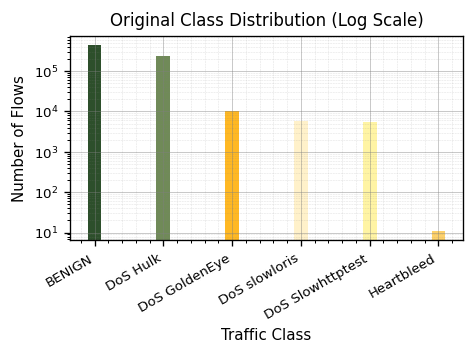

In [36]:
class_distribution = (
    selected_dataframe[TARGET_COLUMN]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)
class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
)

display(class_distribution)

plt.figure(figsize=(4, 3), dpi=FIG_DPI)
plt.bar(
    class_distribution["class_name"],
    class_distribution["count"],
    color=[theme_color(i) for i in range(len(class_distribution))],
    width=.2
)
plt.yscale("log")
plt.title("Original Class Distribution (Log Scale)")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Flows")
plt.xticks(rotation=30, ha="right")
finish_plot()

### Stratified Train, Validation, and Test Splits

The data are separated as:

$$
D
=
D_{train}
\cup
D_{val}
\cup
D_{test},
$$

with:

$$
D_{train}\cap D_{val}
=
D_{train}\cap D_{test}
=
D_{val}\cap D_{test}
=
\varnothing.
$$

The proportions are:

$$
70\% \text{ training},\qquad
15\% \text{ validation},\qquad
15\% \text{ test}.
$$

Stratification is used so that each split retains examples from every class. The test set remains untouched until the final evaluation.

In [9]:
TEST_SIZE = 0.15
VALID_SIZE = 0.15
VALID_FROM_REMAINING = VALID_SIZE / (1.0 - TEST_SIZE)

train_valid_df, test_df = train_test_split(
    selected_dataframe,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=selected_dataframe[TARGET_COLUMN],
)

train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=VALID_FROM_REMAINING,
    random_state=SEED,
    stratify=train_valid_df[TARGET_COLUMN],
)

split_frames = {
    "train": train_df.reset_index(drop=True),
    "validation": valid_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

all_classes = set(selected_dataframe[TARGET_COLUMN].unique())
for split_name, split_df in split_frames.items():
    present_classes = set(split_df[TARGET_COLUMN].unique())
    missing = all_classes - present_classes
    assert not missing, f"{split_name} split is missing classes: {missing}"

split_summary = pd.DataFrame({
    "split": list(split_frames.keys()),
    "samples": [len(frame) for frame in split_frames.values()],
    "percentage": [
        len(frame) / len(selected_dataframe) * 100
        for frame in split_frames.values()
    ],
})
display(split_summary)

,split,samples,percentage
0,train,484891,69.999841
1,validation,103906,15.000079
2,test,103906,15.000079


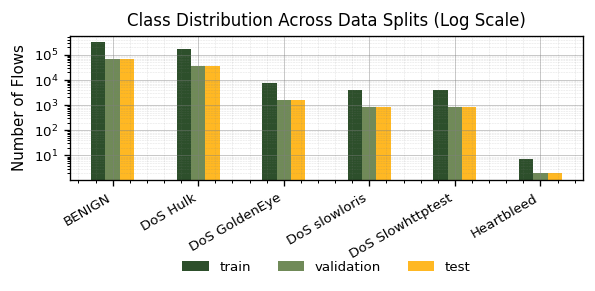

In [41]:
split_class_counts = pd.DataFrame({
    split_name: frame[TARGET_COLUMN].value_counts()
    for split_name, frame in split_frames.items()
}).fillna(0).astype(int)

split_class_counts.plot(
    kind="bar",
    figsize=(5, 3),
    color=[theme_color(i) for i in range(len(split_class_counts.columns))],
)
plt.yscale("log")
plt.title("Class Distribution Across Data Splits (Log Scale)")
plt.xlabel("")
plt.ylabel("Number of Flows")
plt.xticks(rotation=30, ha="right")
finish_plot(legend=True, legend_ncol=3, legend_y=-0.48)

### Label Encoding and Training-Only Standardization

The label encoder is fitted on the training labels. The numerical-feature transformer is also fitted on the training split only.

For feature $j$:

$$
\widetilde{x}_{ij}
=
\frac{x_{ij}-\mu^{train}_j}
{\sigma^{train}_j}.
$$

Using only training statistics prevents information from the validation and test sets from leaking into model fitting.

In [13]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(split_frames["train"][TARGET_COLUMN])
y_valid = label_encoder.transform(split_frames["validation"][TARGET_COLUMN])
y_test = label_encoder.transform(split_frames["test"][TARGET_COLUMN])
class_names = label_encoder.classes_
n_classes = len(class_names)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "standardize",
            Pipeline([("scaler", StandardScaler())]),
            SELECTED_FEATURES,
        )
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(split_frames["train"][SELECTED_FEATURES])
X_valid = preprocessor.transform(split_frames["validation"][SELECTED_FEATURES])
X_test = preprocessor.transform(split_frames["test"][SELECTED_FEATURES])

X_train = np.asarray(X_train, dtype=np.float32)
X_valid = np.asarray(X_valid, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

print("Class mapping:")
display(pd.DataFrame({
    "class_index": np.arange(n_classes),
    "class_name": class_names,
}))
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

Class mapping:


,class_index,class_name
0,0,BENIGN
1,1,DoS GoldenEye
2,2,DoS Hulk
3,3,DoS Slowhttptest
4,4,DoS slowloris
5,5,Heartbleed


Train: (484891, 9) (484891,)
Validation: (103906, 9) (103906,)
Test: (103906, 9) (103906,)


### Training-Only Class Weights

The next cell implements:

$$
w_c
=
\frac{N_{train}}{C\,n_c}.
$$

The weights are passed to `torch.nn.CrossEntropyLoss`. No validation or test labels are used in their calculation.

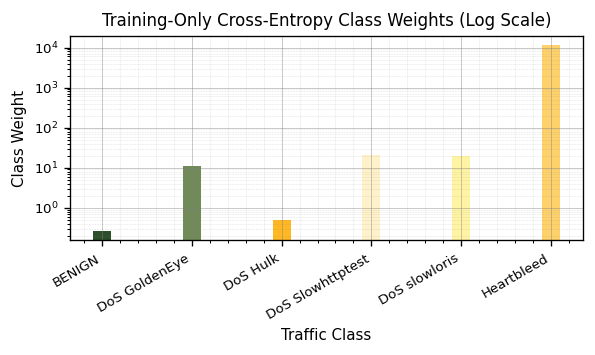

In [16]:
train_class_counts = np.bincount(y_train, minlength=n_classes)
if np.any(train_class_counts == 0):
    raise ValueError("At least one encoded class has zero training samples.")

class_weights_np = (
    len(y_train) / (n_classes * train_class_counts.astype(np.float64))
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
class_weight_table = pd.DataFrame({
    "class_index": np.arange(n_classes),
    "class_name": class_names,
    "training_samples": train_class_counts,
    "cross_entropy_weight": class_weights_np,
})
plt.figure(figsize=(5, 3), dpi=FIG_DPI)
plt.bar(
    class_weight_table["class_name"],
    class_weight_table["cross_entropy_weight"],
    color=[theme_color(i) for i in range(n_classes)],
    width=.2
)
plt.yscale("log")
plt.title("Training-Only Cross-Entropy Class Weights (Log Scale)")
plt.xlabel("Traffic Class")
plt.ylabel("Class Weight")
plt.xticks(rotation=30, ha="right")
finish_plot()

### Tensor Datasets and Reproducible Data Loaders

The training loader is recreated for each model using the same generator seed. This gives each initialization method the same shuffled mini-batch order.

A large batch size is used because the input contains only nine numerical features. Adjust `BATCH_SIZE` if memory is limited.

In [17]:
train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train).long(),
)
valid_dataset = TensorDataset(
    torch.from_numpy(X_valid),
    torch.from_numpy(y_valid).long(),
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test).long(),
)

def create_data_loaders(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    common_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": AMP_ENABLED,
        "drop_last": False,
    }

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        generator=generator,
        **common_kwargs,
    )
    valid_loader = DataLoader(
        valid_dataset,
        shuffle=False,
        **common_kwargs,
    )
    test_loader = DataLoader(
        test_dataset,
        shuffle=False,
        **common_kwargs,
    )
    return train_loader, valid_loader, test_loader

train_loader, valid_loader, test_loader = create_data_loaders(SEED)

batch_features, batch_labels = next(iter(train_loader))
print("Feature batch:", batch_features.shape)
print("Label batch:", batch_labels.shape)

Feature batch: torch.Size([1024, 9])
Label batch: torch.Size([1024])


### MLP Architecture

The fixed architecture is:

$$
d
\rightarrow
128
\rightarrow
64
\rightarrow
32
\rightarrow
C.
$$

ReLU and dropout are applied after every hidden linear layer:

$$
\mathbf{h}^{(\ell)}
=
\operatorname{Dropout}
\left(
\operatorname{ReLU}
\left(
W^{(\ell)}\mathbf{h}^{(\ell-1)}
+
b^{(\ell)}
\right)
\right).
$$

Batch normalization and layer normalization are intentionally omitted because they can partially mask the effect of initialization.

In [18]:
class DDoSMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
    ):
        super().__init__()
        dimensions = [input_dim, *hidden_dims]
        self.hidden_layers = nn.ModuleList([
            nn.Linear(dimensions[i], dimensions[i + 1])
            for i in range(len(hidden_dims))
        ])
        self.activations = nn.ModuleList([
            nn.ReLU() for _ in hidden_dims
        ])
        self.dropouts = nn.ModuleList([
            nn.Dropout(dropout) for _ in hidden_dims
        ])
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for linear, activation, dropout in zip(
            self.hidden_layers,
            self.activations,
            self.dropouts,
        ):
            x = dropout(activation(linear(x)))
        return self.output_layer(x)

    def hidden_forward(self, x):
        x = x.view(x.size(0), -1)
        hidden_outputs = []

        for linear, activation in zip(
            self.hidden_layers,
            self.activations,
        ):
            x = activation(linear(x))
            hidden_outputs.append(x)
        return hidden_outputs

input_dim = X_train.shape[1]
output_dim = n_classes

example_model = DDoSMLP(input_dim, output_dim).to(device)
total_parameters = sum(p.numel() for p in example_model.parameters())
trainable_parameters = sum(
    p.numel() for p in example_model.parameters() if p.requires_grad
)

print(example_model)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
del example_model

DDoSMLP(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
  (activations): ModuleList(
    (0-2): 3 x ReLU()
  )
  (dropouts): ModuleList(
    (0-2): 3 x Dropout(p=0.15, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=6, bias=True)
)
Total parameters: 11,814
Trainable parameters: 11,814


### Initialization Implementations

Only hidden-layer weights are changed. The output layer remains identical across methods because every model is constructed from the same seed and the output weights are not reinitialized. Biases are set to zero for all methods.

This design isolates the effect of hidden-layer weight initialization.

In [19]:
def zero_all_biases(model):
    for module in model.modules():
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

def initialize_nguyen_widrow_weight_only(layer):
    fan_in = layer.in_features
    fan_out = layer.out_features
    beta = 0.7 * (fan_out ** (1.0 / fan_in))
    nn.init.uniform_(layer.weight, -0.5, 0.5)
    row_norms = layer.weight.norm(p=2, dim=1, keepdim=True).clamp_min(1e-12)
    layer.weight.mul_(beta / row_norms)


@torch.no_grad()
def initialize_hidden_weights(model, method):
    zero_all_biases(model)
    for layer in model.hidden_layers:
        fan_in = layer.in_features
        fan_out = layer.out_features
        if method == "default":
            pass
        elif method == "xavier_uniform":
            nn.init.xavier_uniform_(
                layer.weight,
                gain=nn.init.calculate_gain("relu"),
            )
        elif method == "xavier_normal":
            nn.init.xavier_normal_(
                layer.weight,
                gain=nn.init.calculate_gain("relu"),
            )
        elif method == "kaiming_uniform":
            nn.init.kaiming_uniform_(
                layer.weight,
                mode="fan_in",
                nonlinearity="relu",
            )
        elif method == "kaiming_normal":
            nn.init.kaiming_normal_(
                layer.weight,
                mode="fan_in",
                nonlinearity="relu",
            )
        elif method == "lecun_normal":
            nn.init.normal_(
                layer.weight,
                mean=0.0,
                std=1.0 / math.sqrt(fan_in),
            )
        elif method == "orthogonal":
            nn.init.orthogonal_(
                layer.weight,
                gain=nn.init.calculate_gain("relu"),
            )
        elif method == "sparse":
            nn.init.sparse_(
                layer.weight,
                sparsity=0.80,
                std=math.sqrt(2.0 / fan_in),
            )
        elif method == "truncated_xavier_normal":
            std = (
                nn.init.calculate_gain("relu")
                * math.sqrt(2.0 / (fan_in + fan_out))
            )
            nn.init.trunc_normal_(
                layer.weight,
                mean=0.0,
                std=std,
                a=-2.0 * std,
                b=2.0 * std,
            )
        elif method == "nguyen_widrow":
            initialize_nguyen_widrow_weight_only(layer)
        elif method == "lsuv":
            nn.init.orthogonal_(layer.weight, gain=1.0)
        else:
            raise ValueError(f"Unknown initialization method: {method}")
    return model

### LSUV Data-Dependent Rescaling

LSUV uses one fixed training mini-batch, disables dropout during initialization, and sequentially rescales each hidden layer until its post-ReLU activation variance is close to one.

In [20]:
@torch.no_grad()
def apply_lsuv(
    model,
    calibration_batch,
    tolerance=0.10,
    max_iterations=10,
    eps=1e-8,
):
    model.eval()
    calibration_batch = calibration_batch.to(device)

    records = []

    for layer_index, (linear, activation) in enumerate(
        zip(model.hidden_layers, model.activations),
        start=1,
    ):
        for iteration in range(1, max_iterations + 1):
            captured = {}

            def capture_activation(_module, _inputs, output):
                captured["value"] = output.detach()

            handle = activation.register_forward_hook(capture_activation)
            _ = model(calibration_batch)
            handle.remove()

            output = captured["value"]
            variance = output.var(unbiased=False).item()

            records.append({
                "layer": layer_index,
                "iteration": iteration,
                "activation_variance": variance,
            })

            if not np.isfinite(variance) or variance <= eps:
                raise RuntimeError(
                    f"Invalid LSUV variance {variance} at layer {layer_index}."
                )

            if abs(variance - 1.0) <= tolerance:
                break

            linear.weight.div_(math.sqrt(variance + eps))

    model.train()
    return pd.DataFrame(records)

In [21]:
def build_initialized_model(method, seed=SEED, lsuv_batch=None):
    set_seed(seed)
    model = DDoSMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
    ).to(device)
    initialize_hidden_weights(model, method)
    lsuv_records = None
    if method == "lsuv":
        if lsuv_batch is None:
            raise ValueError("LSUV requires a calibration mini-batch.")
        lsuv_records = apply_lsuv(model, lsuv_batch)
    return model, lsuv_records

diagnostic_batch = torch.from_numpy(
    X_train[: min(2048, len(X_train))]
).float()
test_model, test_lsuv_records = build_initialized_model(
    "lsuv",
    seed=SEED,
    lsuv_batch=diagnostic_batch,
)
print("LSUV initialized successfully.")
if test_lsuv_records is not None:
    display(test_lsuv_records.tail())
del test_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

LSUV initialized successfully.


,layer,iteration,activation_variance
1,1,2,0.999999
2,2,1,0.425264
3,2,2,1.000000
4,3,1,0.397829
5,3,2,1.000000


### Initialization Diagnostics Before Training

Before optimization, the notebook measures:

1. hidden weight mean and standard deviation;
2. fraction of exact zero weights;
3. post-ReLU activation variance for each hidden layer.

For hidden activation tensor $H^{(\ell)}$ with $m$ values:

$$
\widehat{\operatorname{Var}}
\left(H^{(\ell)}\right)
=
\frac{1}{m}
\sum_{r=1}^{m}
\left(
H^{(\ell)}_r
-
\overline{H}^{(\ell)}
\right)^2.
$$

These diagnostics help connect the theoretical initialization formula to the observed initial signal scale.

In [22]:
@torch.no_grad()
def collect_initialization_diagnostics(model, method, feature_batch):
    model.eval()
    feature_batch = feature_batch.to(device)
    rows = []
    hidden_outputs = model.hidden_forward(feature_batch)
    for layer_index, (layer, hidden_output) in enumerate(
        zip(model.hidden_layers, hidden_outputs),
        start=1,
    ):
        weights = layer.weight.detach().cpu()
        rows.append({
            "method": method,
            "layer": f"hidden_{layer_index}",
            "fan_in": layer.in_features,
            "fan_out": layer.out_features,
            "weight_mean": weights.mean().item(),
            "weight_std": weights.std(unbiased=False).item(),
            "zero_fraction": (weights == 0).float().mean().item(),
            "activation_mean": hidden_output.mean().item(),
            "activation_variance": hidden_output.var(unbiased=False).item(),
        })

    return rows
diagnostic_rows = []
for method in INIT_METHODS:
    model, _ = build_initialized_model(
        method,
        seed=SEED,
        lsuv_batch=diagnostic_batch,
    )
    diagnostic_rows.extend(
        collect_initialization_diagnostics(
            model,
            method,
            diagnostic_batch,
        )
    )
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
initialization_diagnostics = pd.DataFrame(diagnostic_rows)
display(initialization_diagnostics)

,method,layer,fan_in,fan_out,weight_mean,weight_std,zero_fraction,activation_mean,activation_variance
0,default,hidden_1,9,128,-0.008985,0.193633,0.000000,0.189993,0.090262
1,default,hidden_2,128,64,0.000299,0.050941,0.000000,0.082895,0.017112
2,default,hidden_3,64,32,-0.001866,0.071967,0.000000,0.023887,0.002053
3,xavier_uniform,hidden_1,9,128,-0.004866,0.170146,0.000000,0.173525,0.078816
4,xavier_uniform,hidden_2,128,64,-0.001238,0.144126,0.000000,0.193820,0.112820
5,xavier_uniform,hidden_3,64,32,-0.000254,0.204093,0.000000,0.211311,0.142124
6,xavier_normal,hidden_1,9,128,0.002818,0.175611,0.000000,0.161366,0.078234
7,xavier_normal,hidden_2,128,64,-0.000007,0.145571,0.000000,0.190644,0.099655
8,xavier_normal,hidden_3,64,32,-0.000196,0.202257,0.000000,0.222692,0.138512
9,kaiming_uniform,hidden_1,9,128,-0.013424,0.469402,0.000000,0.478725,0.599876


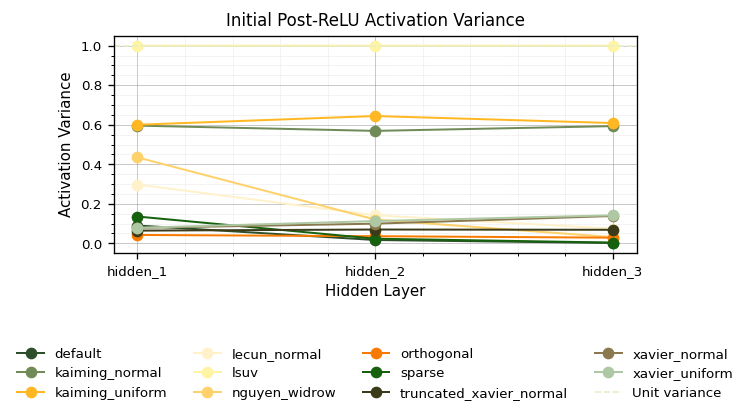

In [26]:
activation_variance_pivot = initialization_diagnostics.pivot(
    index="method",
    columns="layer",
    values="activation_variance",
)
plt.figure(figsize=(6, 4), dpi=FIG_DPI)
for method_index, (method, row) in enumerate(
    activation_variance_pivot.iterrows()
):
    plt.plot(
        row.index,
        row.values,
        marker="o",
        linewidth=1.2,
        label=method,
        color=theme_color(method_index),
    )
plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
    color=theme_color(len(INIT_METHODS)),
    label="Unit variance",
)
plt.title("Initial Post-ReLU Activation Variance")
plt.xlabel("Hidden Layer")
plt.ylabel("Activation Variance")
finish_plot(legend=True, legend_ncol=4, legend_y=-0.38)

### Training and Evaluation Metrics

The training process records **loss** and **accuracy** for every epoch. These values are stored in a `history` object for each initialization method.

For a dataset containing $N$ observations, the mean weighted cross-entropy loss is:

$$
\mathcal{L}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}_{WCE}^{(i)}.
$$

Training accuracy at epoch $t$ is:

$$
Accuracy_{train}^{(t)}
=
\frac{
\sum_{i=1}^{N_{train}}
\mathbb{1}\left(\widehat{y}_i=y_i\right)
}{N_{train}},
$$

and validation accuracy is:

$$
Accuracy_{val}^{(t)}
=
\frac{
\sum_{i=1}^{N_{val}}
\mathbb{1}\left(\widehat{y}_i=y_i\right)
}{N_{val}}.
$$

Here, $\mathbb{1}(\cdot)$ is an indicator function that equals one when the prediction is correct and zero otherwise.

For final multiclass evaluation:

$$
Accuracy
=
\frac{\sum_{c=1}^{C}TP_c}{N}.
$$

Per-class recall is:

$$
Recall_c
=
\frac{TP_c}{TP_c+FN_c}.
$$

Macro recall treats all classes equally:

$$
Recall_{macro}
=
\frac{1}{C}
\sum_{c=1}^{C}Recall_c.
$$

Macro-F1 is:

$$
F1_{macro}
=
\frac{1}{C}
\sum_{c=1}^{C}
\frac{
2\,Precision_c\,Recall_c
}{
Precision_c+Recall_c
}.
$$

Balanced accuracy equals macro recall in the standard multiclass setting. It remains important because ordinary accuracy may be dominated by benign and high-frequency attack classes.


In [27]:
def compute_multiclass_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

def wilson_accuracy_interval(y_true, y_pred, z=1.96):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    if n == 0:
        raise ValueError("Wilson interval requires at least one sample.")
    k = int(np.sum(y_true == y_pred))
    p_hat = k / n
    denominator = 1.0 + (z**2 / n)
    center = (
        p_hat + (z**2 / (2.0 * n))
    ) / denominator
    half_width = (
        z
        * math.sqrt(
            (p_hat * (1.0 - p_hat) / n)
            + (z**2 / (4.0 * n**2))
        )
        / denominator
    )
    return {
        "correct": k,
        "n": n,
        "accuracy": p_hat,
        "ci_lower": max(0.0, center - half_width),
        "ci_upper": min(1.0, center + half_width),
    }

### Efficient Training, History Tracking, and Checkpointing

Each initialization method uses the same:

- weighted cross-entropy objective;
- AdamW optimizer;
- automatic mixed precision when CUDA is available;
- gradient clipping;
- `ReduceLROnPlateau` scheduler;
- maximum of 100 epochs;
- early stopping;
- model architecture, data split, and random seed.

For every epoch, the notebook stores the following values in the method's `history` object:

- training loss;
- validation loss;
- training accuracy;
- validation accuracy;
- validation balanced accuracy;
- validation macro-F1;
- learning rate and gradient norm.

The best checkpoint is selected using the **lowest validation loss**:

$$
t^*
=
\arg\min_{1\leq t\leq T}
\mathcal{L}_{val}^{(t)}.
$$

The model is saved when:

$$
\mathcal{L}_{val}^{(t)}
<
\mathcal{L}_{val}^{best}.
$$

When validation losses are numerically tied, the checkpoint with the higher validation macro-F1 is retained. This tie-breaker acknowledges the imbalanced multiclass setting without allowing the test set to influence model selection.


In [30]:
def amp_context():
    if AMP_ENABLED:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )
    return nullcontext()

def train_one_epoch(model, loader, optimizer, criterion, grad_scaler):
    model.train()
    total_loss = 0.0
    total_samples = 0
    total_correct = 0
    gradient_norm_sum = 0.0
    gradient_steps = 0
    for features, labels in loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with amp_context():
            logits = model(features)
            loss = criterion(logits, labels)
        grad_scaler.scale(loss).backward()
        grad_scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=MAX_GRAD_NORM,
        )
        grad_scaler.step(optimizer)
        grad_scaler.update()
        batch_size = labels.size(0)
        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        total_correct += (predictions == labels).sum().item()
        gradient_norm_sum += float(grad_norm)
        gradient_steps += 1
    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "mean_gradient_norm": gradient_norm_sum / max(gradient_steps, 1),
    }


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_labels = []
    all_predictions = []
    all_probabilities = []
    for features, labels in loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with amp_context():
            logits = model(features)
            loss = criterion(logits, labels)
        probabilities = torch.softmax(logits.float(), dim=1)
        predictions = probabilities.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())
        all_probabilities.append(probabilities.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_predictions).numpy()
    probabilities = torch.cat(all_probabilities).numpy()
    metrics = compute_multiclass_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / total_samples
    return metrics, y_true, y_pred, probabilities

In [31]:
def safe_method_name(method):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", method)

def create_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except TypeError:
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def train_initialization_method(method, seed=SEED):
    """Train one MLP initialization variant and return its epoch history."""
    train_loader, valid_loader, _ = create_data_loaders(seed)
    model, lsuv_records = build_initialized_model(
        method,
        seed=seed,
        lsuv_batch=diagnostic_batch,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
    )
    grad_scaler = create_grad_scaler()
    checkpoint_path = CHECKPOINT_DIR / f"{safe_method_name(method)}_best.pt"
    history_path = RESULTS_DIR / f"{safe_method_name(method)}_history.csv"
    method_history = []
    best_val_loss = np.inf
    best_val_macro_f1 = -np.inf
    best_val_accuracy = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    training_start = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.perf_counter()
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            grad_scaler,
        )
        val_metrics, _, _, _ = evaluate_model(
            model,
            valid_loader,
            criterion,
        )
        current_lr = optimizer.param_groups[0]["lr"]
        epoch_seconds = time.perf_counter() - epoch_start
        improved_loss = val_metrics["loss"] < best_val_loss - 1e-8
        tied_loss_higher_f1 = (
            abs(val_metrics["loss"] - best_val_loss) <= 1e-8
            and val_metrics["macro_f1"] > best_val_macro_f1 + 1e-8
        )
        improved = improved_loss or tied_loss_higher_f1
        checkpoint_saved = False
        if improved:
            best_val_loss = val_metrics["loss"]
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_val_accuracy = val_metrics["accuracy"]
            best_epoch = epoch
            epochs_without_improvement = 0
            checkpoint_saved = True
            torch.save({
                "model_state_dict": model.state_dict(),
                "method": method,
                "seed": seed,
                "epoch": epoch,
                "best_val_loss": best_val_loss,
                "best_val_accuracy": best_val_accuracy,
                "best_val_macro_f1": best_val_macro_f1,
                "selected_features": SELECTED_FEATURES,
                "class_names": class_names.tolist(),
                "hidden_dims": list(HIDDEN_DIMS),
                "dropout": DROPOUT,
            }, checkpoint_path)
        else:
            epochs_without_improvement += 1
        method_history.append({
            "method": method,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "mean_gradient_norm": train_metrics["mean_gradient_norm"],
            "learning_rate": current_lr,
            "epoch_seconds": epoch_seconds,
            "checkpoint_saved": checkpoint_saved,
        })

        scheduler.step(val_metrics["loss"])
        if (
            epoch == 1
            or epoch % PRINT_EVERY == 0
            or checkpoint_saved
            or epoch == EPOCHS
        ):
            status = "saved" if checkpoint_saved else "-"
            print(
                f"{method:26s} | "
                f"epoch {epoch:03d}/{EPOCHS} | "
                f"train_loss={train_metrics['loss']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"val_acc={val_metrics['accuracy']:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
                f"lr={current_lr:.2e} | "
                f"checkpoint={status}"
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping {method} at epoch {epoch}; "
                f"best epoch was {best_epoch}."
            )
            break

    training_seconds = time.perf_counter() - training_start
    method_history_df = pd.DataFrame(method_history)
    method_history_df.to_csv(history_path, index=False)

    if lsuv_records is not None:
        lsuv_records.to_csv(
            RESULTS_DIR / "lsuv_initialization_trace.csv",
            index=False,
        )

    summary = {
        "method": method,
        "epochs_completed": len(method_history_df),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "best_val_macro_f1": best_val_macro_f1,
        "training_seconds": training_seconds,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
    }

    del model, optimizer, scheduler, grad_scaler
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return method_history_df, summary


### Run the Initialization Experiments

The following cell trains one model at a time and stores its epoch records in the dictionary named `history`:

```python
history[initialization_method] = method_history_df
```


In [32]:
history = {}
training_summaries = []
for method in INIT_METHODS:
    print("\n" + "=" * 100)
    print(f"Training initialization method: {method}")
    print("=" * 100)
    method_history_df, summary = train_initialization_method(
        method,
        seed=SEED,
    )
    history[method] = method_history_df
    training_summaries.append(summary)
all_history_df = pd.concat(
    history.values(),
    ignore_index=True,
)
training_summary_df = pd.DataFrame(training_summaries)
all_history_df.to_csv(
    RESULTS_DIR / "all_training_histories.csv",
    index=False,
)
training_summary_df.to_csv(
    RESULTS_DIR / "training_summary.csv",
    index=False,
)

display(
    training_summary_df.sort_values(
        ["best_val_loss", "best_val_macro_f1"],
        ascending=[True, False],
    )
)


Training initialization method: default
default                    | epoch 001/100 | train_loss=0.7373 | val_loss=0.5072 | train_acc=0.8008 | val_acc=0.8659 | val_macro_f1=0.4757 | lr=1.00e-03 | checkpoint=saved
default                    | epoch 002/100 | train_loss=0.4804 | val_loss=0.4075 | train_acc=0.8741 | val_acc=0.8897 | val_macro_f1=0.5195 | lr=1.00e-03 | checkpoint=saved
default                    | epoch 003/100 | train_loss=0.4249 | val_loss=0.3530 | train_acc=0.8861 | val_acc=0.8931 | val_macro_f1=0.5358 | lr=1.00e-03 | checkpoint=saved
default                    | epoch 005/100 | train_loss=0.3699 | val_loss=0.3245 | train_acc=0.9004 | val_acc=0.8976 | val_macro_f1=0.5058 | lr=1.00e-03 | checkpoint=saved
default                    | epoch 006/100 | train_loss=0.3353 | val_loss=0.3004 | train_acc=0.9049 | val_acc=0.9129 | val_macro_f1=0.5521 | lr=1.00e-03 | checkpoint=saved
default                    | epoch 007/100 | train_loss=0.3390 | val_loss=0.2946 | train_acc=0.9094

,method,epochs_completed,best_epoch,best_val_loss,best_val_accuracy,best_val_macro_f1,training_seconds,checkpoint_path,history_path
8,truncated_xavier_normal,100,100,0.091049,0.971436,0.901136,2516.710219,checkpoints_weight_initialization_ddos\truncat...,results_weight_initialization_ddos\truncated_x...
2,xavier_normal,100,100,0.092537,0.971407,0.863753,2781.444748,checkpoints_weight_initialization_ddos\xavier_...,results_weight_initialization_ddos\xavier_norm...
1,xavier_uniform,100,97,0.093203,0.969723,0.860235,2616.771340,checkpoints_weight_initialization_ddos\xavier_...,results_weight_initialization_ddos\xavier_unif...
0,default,100,100,0.093449,0.970598,0.840448,2803.788622,checkpoints_weight_initialization_ddos\default...,results_weight_initialization_ddos\default_his...
5,lecun_normal,100,100,0.094033,0.969655,0.895045,2937.144021,checkpoints_weight_initialization_ddos\lecun_n...,results_weight_initialization_ddos\lecun_norma...
4,kaiming_normal,100,100,0.094517,0.973592,0.898831,2937.538985,checkpoints_weight_initialization_ddos\kaiming...,results_weight_initialization_ddos\kaiming_nor...
9,nguyen_widrow,100,92,0.095173,0.970136,0.892178,2783.014633,checkpoints_weight_initialization_ddos\nguyen_...,results_weight_initialization_ddos\nguyen_widr...
10,lsuv,100,100,0.095210,0.970310,0.893768,2658.019726,checkpoints_weight_initialization_ddos\lsuv_be...,results_weight_initialization_ddos\lsuv_histor...
3,kaiming_uniform,100,97,0.096260,0.975093,0.904411,3016.703416,checkpoints_weight_initialization_ddos\kaiming...,results_weight_initialization_ddos\kaiming_uni...
7,sparse,100,92,0.097410,0.975026,0.905396,2766.454499,checkpoints_weight_initialization_ddos\sparse_...,results_weight_initialization_ddos\sparse_hist...


### Loss and Accuracy History

The following plots are produced directly from the `history` object.

For every initialization method, validation loss shows optimization progress, while validation accuracy shows the proportion of correctly classified validation flows. Because accuracy can conceal poor minority-class recognition, validation macro-F1 is retained as an additional imbalance-aware diagnostic later in this section.

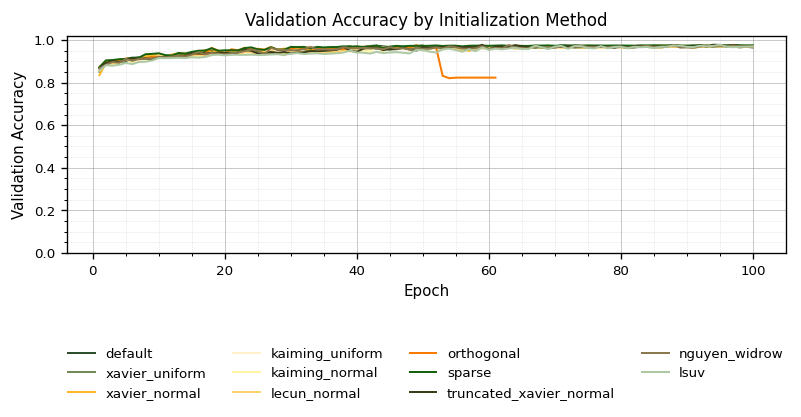

In [42]:
plt.figure(figsize=(7, 4), dpi=FIG_DPI)

for method_index, method in enumerate(INIT_METHODS):
    method_history = history[method]
    plt.plot(
        method_history["epoch"],
        method_history["val_accuracy"],
        label=method,
        color=theme_color(method_index),
        linewidth=1.2,
    )

plt.title("Validation Accuracy by Initialization Method")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1.02)
finish_plot(legend=True, legend_ncol=4, legend_y=-0.38)


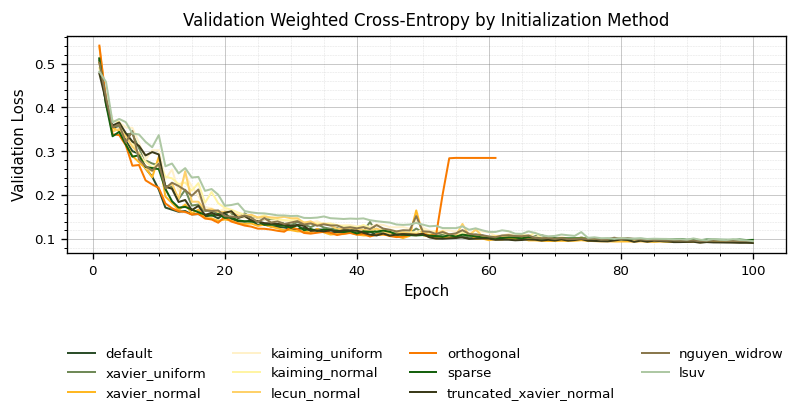

In [44]:
plt.figure(figsize=(7, 4), dpi=FIG_DPI)

for method_index, method in enumerate(INIT_METHODS):
    method_history = history[method]
    plt.plot(
        method_history["epoch"],
        method_history["val_loss"],
        label=method,
        color=theme_color(method_index),
        linewidth=1.2,
    )

plt.title("Validation Weighted Cross-Entropy by Initialization Method")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
finish_plot(legend=True, legend_ncol=4, legend_y=-0.38)


### Detailed Training History of the Validation-Selected Initialization

The method with the lowest recorded validation loss is selected without inspecting the test set.

In [46]:
validation_selected_row = training_summary_df.sort_values(
    ["best_val_loss", "best_val_macro_f1"],
    ascending=[True, False],
).iloc[0]

validation_selected_method = validation_selected_row["method"]
selected_history_df = history[validation_selected_method]

print("Validation-selected initialization:", validation_selected_method)
display(selected_history_df.tail())

Validation-selected initialization: truncated_xavier_normal


,method,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_balanced_accuracy,val_macro_f1,mean_gradient_norm,learning_rate,epoch_seconds,checkpoint_saved
95,truncated_xavier_normal,96,0.107848,0.092003,0.967184,0.970550,0.973072,0.863806,1.774284,0.000250,28.667259,False
96,truncated_xavier_normal,97,0.109596,0.091861,0.966161,0.977114,0.974218,0.883183,1.874318,0.000250,29.672886,False
97,truncated_xavier_normal,98,0.106007,0.091386,0.967353,0.971436,0.975132,0.868016,1.797818,0.000125,31.703828,True
98,truncated_xavier_normal,99,0.106120,0.091462,0.966836,0.971436,0.973540,0.866782,1.872970,0.000125,30.055889,False
99,truncated_xavier_normal,100,0.106066,0.091049,0.967232,0.971436,0.975136,0.901136,1.854246,0.000125,29.186807,True


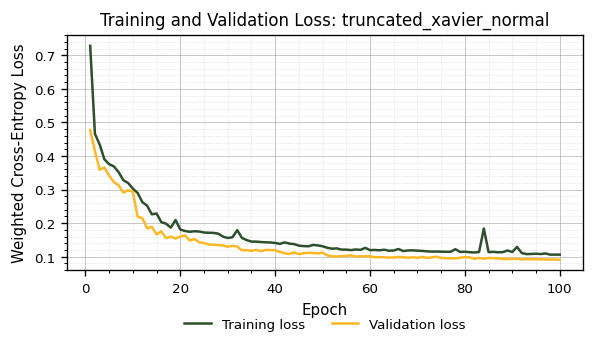

In [101]:

plt.figure(figsize=(5, 3), dpi=FIG_DPI)
plt.plot(
    selected_history_df["epoch"],
    selected_history_df["train_loss"],
    label="Training loss",
    color=PALETTES.nature[0],
)
plt.plot(
    selected_history_df["epoch"],
    selected_history_df["val_loss"],
    label="Validation loss",
    color=PALETTES.nature[2],
)
plt.title(f"Training and Validation Loss: {validation_selected_method}")
plt.xlabel("Epoch")
plt.ylabel("Weighted Cross-Entropy Loss")
finish_plot(legend=True, legend_ncol=2, legend_y=-0.15)

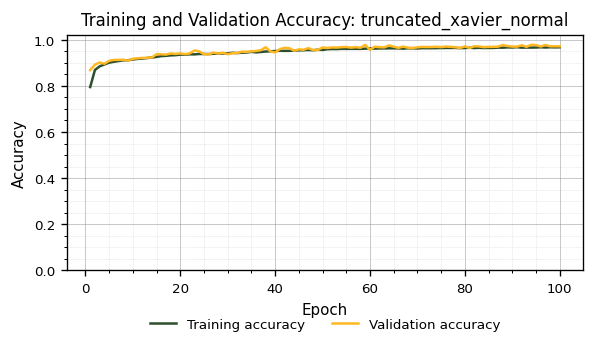

In [102]:
plt.figure(figsize=(5, 3), dpi=FIG_DPI)
plt.plot(
    selected_history_df["epoch"],
    selected_history_df["train_accuracy"],
    label="Training accuracy",
    color=PALETTES.nature[0],
)
plt.plot(
    selected_history_df["epoch"],
    selected_history_df["val_accuracy"],
    label="Validation accuracy",
    color=PALETTES.nature[2],
)
plt.title(f"Training and Validation Accuracy: {validation_selected_method}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.02)
finish_plot(legend=True, legend_ncol=2, legend_y=-0.15)


### Macro-F1 Convergence as an Imbalance-Aware Diagnostic

Accuracy is included because it provides an intuitive measure of total correctness. However, the selected network-flow dataset is imbalanced. Therefore, macro-F1 is also inspected:

$$
F1_{macro}^{(t)}
=
\frac{1}{C}
\sum_{c=1}^{C}
F1_c^{(t)}.
$$

This curve gives every class equal influence, including rare attack classes.


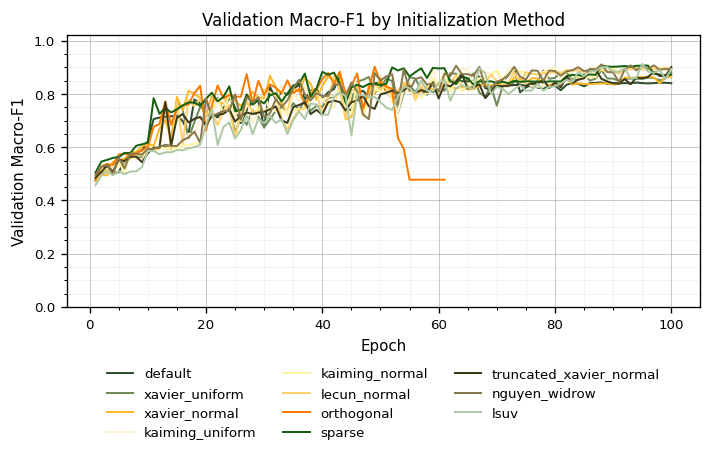

In [105]:
plt.figure(figsize=(6, 4), dpi=FIG_DPI)

for method_index, method in enumerate(INIT_METHODS):
    method_history = history[method]
    plt.plot(
        method_history["epoch"],
        method_history["val_macro_f1"],
        label=method,
        color=theme_color(method_index),
        linewidth=1.2,
    )
plt.title("Validation Macro-F1 by Initialization Method")
plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1")
plt.ylim(0, 1.02)
finish_plot(legend=True, legend_ncol=3, legend_y=-0.18)


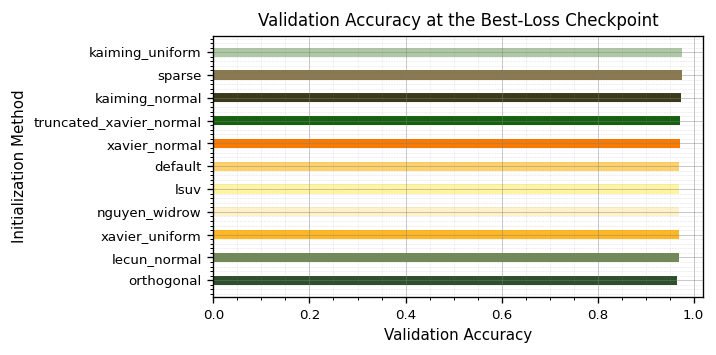

In [55]:
ordered_training_summary = training_summary_df.sort_values(
    "best_val_accuracy",
    ascending=True,
)

plt.figure(figsize=(6, 3), dpi=FIG_DPI)
plt.barh(
    ordered_training_summary["method"],
    ordered_training_summary["best_val_accuracy"],
    color=[
        theme_color(i)
        for i in range(len(ordered_training_summary))
    ],
    height=.4
)
plt.xlim(0, 1.02)
plt.title("Validation Accuracy at the Best-Loss Checkpoint")
plt.xlabel("Validation Accuracy")
plt.ylabel("Initialization Method")
finish_plot()

### Final Evaluation of the Best Checkpoint from Every Method

Every checkpoint is loaded and evaluated once on the untouched test set. The table includes the 95% Wilson interval for accuracy.

In [56]:
def load_checkpoint_model(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    model = DDoSMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden_dims=tuple(checkpoint["hidden_dims"]),
        dropout=checkpoint["dropout"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


criterion = nn.CrossEntropyLoss(weight=class_weights)
_, _, test_loader = create_data_loaders(SEED)

test_result_rows = []
prediction_store = {}
probability_store = {}

for summary in training_summaries:
    method = summary["method"]
    model, checkpoint = load_checkpoint_model(
        summary["checkpoint_path"]
    )
    test_metrics, y_true, y_pred, probabilities = evaluate_model(
        model,
        test_loader,
        criterion,
    )
    wilson = wilson_accuracy_interval(y_true, y_pred)

    test_result_rows.append({
        "method": method,
        "best_epoch": checkpoint["epoch"],
        "test_loss": test_metrics["loss"],
        "accuracy": test_metrics["accuracy"],
        "accuracy_ci_lower": wilson["ci_lower"],
        "accuracy_ci_upper": wilson["ci_upper"],
        "balanced_accuracy": test_metrics["balanced_accuracy"],
        "macro_precision": test_metrics["macro_precision"],
        "macro_recall": test_metrics["macro_recall"],
        "macro_f1": test_metrics["macro_f1"],
        "weighted_f1": test_metrics["weighted_f1"],
        "mcc": test_metrics["mcc"],
    })

    prediction_store[method] = y_pred
    probability_store[method] = probabilities

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

test_results_df = pd.DataFrame(test_result_rows).sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False,
).reset_index(drop=True)

test_results_df.to_csv(
    RESULTS_DIR / "test_results_with_accuracy_ci.csv",
    index=False,
)

display(test_results_df)

,method,best_epoch,test_loss,accuracy,accuracy_ci_lower,accuracy_ci_upper,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc
0,kaiming_normal,100,0.085022,0.972504,0.971492,0.973481,0.977535,0.848282,0.977535,0.897151,0.974718,0.945041
1,lecun_normal,100,0.086227,0.968308,0.967225,0.969356,0.977181,0.849221,0.977181,0.893285,0.971945,0.936874
2,sparse,92,0.090292,0.973515,0.972521,0.974474,0.977594,0.802122,0.977594,0.869512,0.975817,0.947067
3,truncated_xavier_normal,100,0.080700,0.969655,0.968595,0.970681,0.977782,0.798204,0.977782,0.863534,0.973026,0.939430
4,nguyen_widrow,92,0.087304,0.968808,0.967734,0.969848,0.975436,0.789122,0.975436,0.857719,0.972136,0.937841
5,xavier_uniform,97,0.083781,0.967827,0.966736,0.968882,0.976054,0.791213,0.976054,0.857189,0.971732,0.936045
6,kaiming_uniform,97,0.085817,0.973418,0.972423,0.974379,0.977410,0.772344,0.977410,0.846524,0.975631,0.946884
7,orthogonal,46,0.093094,0.964247,0.963100,0.965358,0.975025,0.771935,0.975025,0.843726,0.968900,0.929353
8,xavier_normal,100,0.085669,0.969934,0.968879,0.970955,0.977120,0.765922,0.977120,0.838918,0.973185,0.939999
9,lsuv,100,0.087932,0.968808,0.967734,0.969848,0.975630,0.762559,0.975630,0.835851,0.972209,0.937803


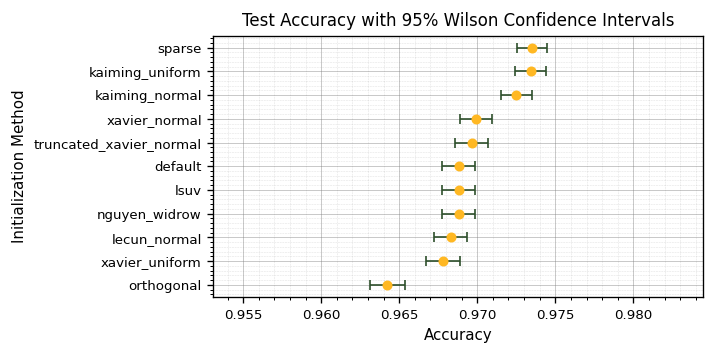

In [107]:
plot_results = test_results_df.sort_values(
    "accuracy",
    ascending=True,
)
lower_error = (
    plot_results["accuracy"]
    - plot_results["accuracy_ci_lower"]
)
upper_error = (
    plot_results["accuracy_ci_upper"]
    - plot_results["accuracy"]
)
plt.figure(figsize=(6, 3), dpi=FIG_DPI)
plt.errorbar(
    plot_results["accuracy"],
    plot_results["method"],
    xerr=np.vstack([lower_error, upper_error]),
    fmt="o",
    capsize=3,
    linewidth=1.0,
    markersize=5,
    color=theme_color(2),
    ecolor=theme_color(0),
)
plt.title("Test Accuracy with 95% Wilson Confidence Intervals")
plt.xlabel("Accuracy")
plt.ylabel("Initialization Method")
plt.xlim(
    max(0.0, plot_results["accuracy_ci_lower"].min() - 0.01),
    min(1.0, plot_results["accuracy_ci_upper"].max() + 0.01),
)
finish_plot()

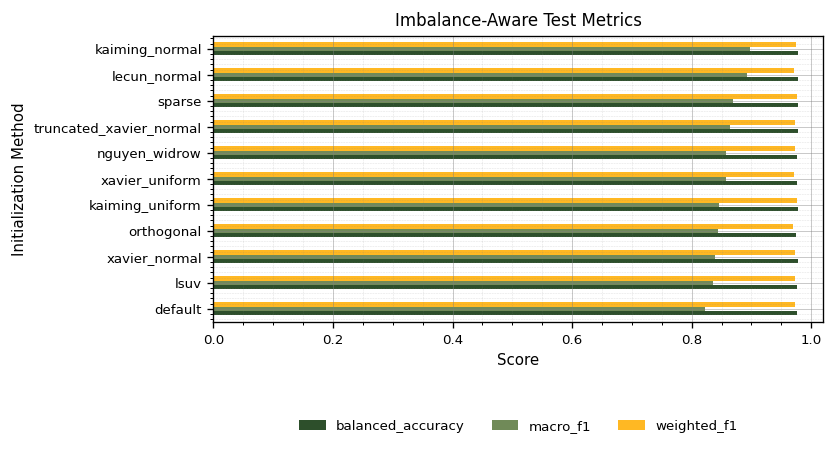

In [61]:
metric_plot_df = (
    test_results_df[
        ["method", "balanced_accuracy", "macro_f1", "weighted_f1"]
    ]
    .set_index("method")
    .sort_values("macro_f1")
)

metric_plot_df.plot(
    kind="barh",
    figsize=(7, 4),
    color=[theme_color(i) for i in range(3)],
)
plt.title("Imbalance-Aware Test Metrics")
plt.xlabel("Score")
plt.ylabel("Initialization Method")
plt.xlim(0, 1.02)
finish_plot(legend=True, legend_ncol=3, legend_y=-0.30)

### Interpreting Accuracy Confidence Intervals

The Wilson interval quantifies uncertainty in the observed test accuracy for each model. Overlapping confidence intervals do **not** by themselves prove that two paired classifiers are equivalent. Therefore, the notebook also performs an exact McNemar comparison between:

- the framework-default baseline;
- the initialization method selected using the lowest validation loss.

### Validation-Based Model Selection and Exact McNemar Test

The initialization method used for subsequent detailed analysis is selected by the lowest validation loss, not by test performance:

$$
m^*
=
\arg\min_m
\mathcal{L}^{val}(m).
$$

When two methods have numerically equal validation loss, validation macro-F1 is used as the tie-breaker.

For paired test predictions, define:

- $b$: baseline wrong and selected model correct;
- $c$: baseline correct and selected model wrong.

Under the null hypothesis of symmetric disagreement:

$$
b
\sim
\operatorname{Binomial}
\left(
b+c,\frac{1}{2}
\right).
$$

The exact two-sided binomial test is the exact McNemar test.


In [62]:
selected_validation_row = training_summary_df.sort_values(
    ["best_val_loss", "best_val_macro_f1"],
    ascending=[True, False],
).iloc[0]

selected_method = selected_validation_row["method"]
baseline_method = "default"

baseline_predictions = prediction_store[baseline_method]
selected_predictions = prediction_store[selected_method]

baseline_correct = baseline_predictions == y_test
selected_correct = selected_predictions == y_test

b = int(np.sum((~baseline_correct) & selected_correct))
c = int(np.sum(baseline_correct & (~selected_correct)))

if b + c > 0:
    mcnemar_result = binomtest(
        k=b,
        n=b + c,
        p=0.5,
        alternative="two-sided",
    )
    mcnemar_p_value = mcnemar_result.pvalue
else:
    mcnemar_p_value = 1.0

mcnemar_summary = pd.DataFrame([{
    "baseline_method": baseline_method,
    "validation_selected_method": selected_method,
    "selection_criterion": "minimum validation loss",
    "baseline_wrong_selected_correct_b": b,
    "baseline_correct_selected_wrong_c": c,
    "exact_mcnemar_p_value": mcnemar_p_value,
}])

display(mcnemar_summary)
print("Validation-selected method:", selected_method)


,baseline_method,validation_selected_method,selection_criterion,baseline_wrong_selected_correct_b,baseline_correct_selected_wrong_c,exact_mcnemar_p_value
0,default,truncated_xavier_normal,minimum validation loss,150,64,3.880523e-09


Validation-selected method: truncated_xavier_normal


### Per-Class Performance

Macro metrics summarize performance, but the research question also concerns minority-class recognition. The next cells calculate per-class precision, recall, F1-score, and support for every initialization method.

Recall is especially useful here because it measures the proportion of each attack class that was detected.

In [64]:
per_class_rows = []

for method in INIT_METHODS:
    report = classification_report(
        y_test,
        prediction_store[method],
        labels=np.arange(n_classes),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    for class_name in class_names:
        class_metrics = report[class_name]
        per_class_rows.append({
            "method": method,
            "class_name": class_name,
            "precision": class_metrics["precision"],
            "recall": class_metrics["recall"],
            "f1_score": class_metrics["f1-score"],
            "support": class_metrics["support"],
        })

per_class_results_df = pd.DataFrame(per_class_rows)
per_class_results_df.to_csv(
    RESULTS_DIR / "per_class_test_metrics.csv",
    index=False,
)

display(
    per_class_results_df[
        per_class_results_df["method"] == selected_method
    ]
)

,method,class_name,precision,recall,f1_score,support
48,truncated_xavier_normal,BENIGN,0.999366,0.979365,0.989265,66005.0
49,truncated_xavier_normal,DoS GoldenEye,0.447726,0.981865,0.615010,1544.0
50,truncated_xavier_normal,DoS Hulk,0.972654,0.950232,0.961312,34661.0
51,truncated_xavier_normal,DoS Slowhttptest,0.939535,0.979394,0.959050,825.0
52,truncated_xavier_normal,DoS slowloris,0.763276,0.975834,0.856566,869.0
53,truncated_xavier_normal,Heartbleed,0.666667,1.000000,0.800000,2.0


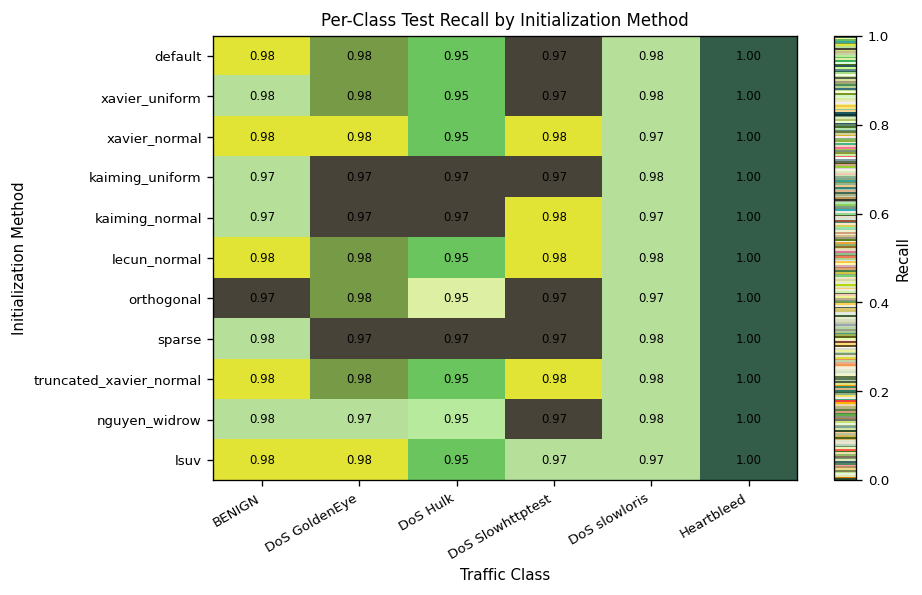

In [98]:
recall_heatmap = per_class_results_df.pivot(
    index="method",
    columns="class_name",
    values="recall",
).loc[INIT_METHODS]

plt.figure(figsize=(8, 5), dpi=FIG_DPI)
image = plt.imshow(
    recall_heatmap.values,
    aspect="auto",
    vmin=0,
    vmax=1,
    cmap=THEME_CMAP,
)
plt.colorbar(image, label="Recall")
plt.xticks(
    np.arange(len(recall_heatmap.columns)),
    recall_heatmap.columns,
    rotation=30,
    ha="right",
)
plt.yticks(
    np.arange(len(recall_heatmap.index)),
    recall_heatmap.index,
)
plt.title("Per-Class Test Recall by Initialization Method")
plt.xlabel("Traffic Class")
plt.ylabel("Initialization Method")

for row in range(recall_heatmap.shape[0]):
    for column in range(recall_heatmap.shape[1]):
        value = recall_heatmap.iloc[row, column]
        plt.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="k"
        )

plt.tight_layout()
plt.show()

### Confusion Matrix for the Validation-Selected Model

The confusion matrix uses the model selected entirely from validation performance.

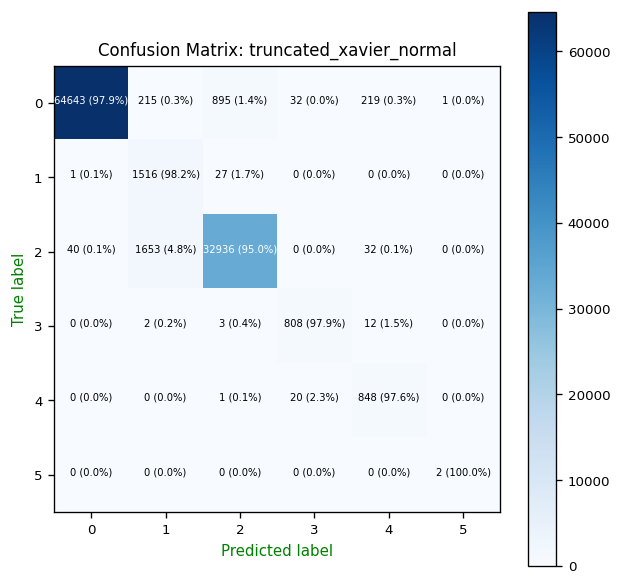

In [91]:
selected_summary = training_summary_df[
    training_summary_df["method"] == selected_method
].iloc[0]

selected_model, selected_checkpoint = load_checkpoint_model(
    selected_summary["checkpoint_path"]
)

selected_predictions = prediction_store[selected_method]
plot_complicated_confusion_matrix(
     y_test,
    selected_predictions, [i for i, _ in enumerate(class_names)],
    fontsize=6, figsize=(6, 6), title=f"Confusion Matrix: {selected_method}",
)

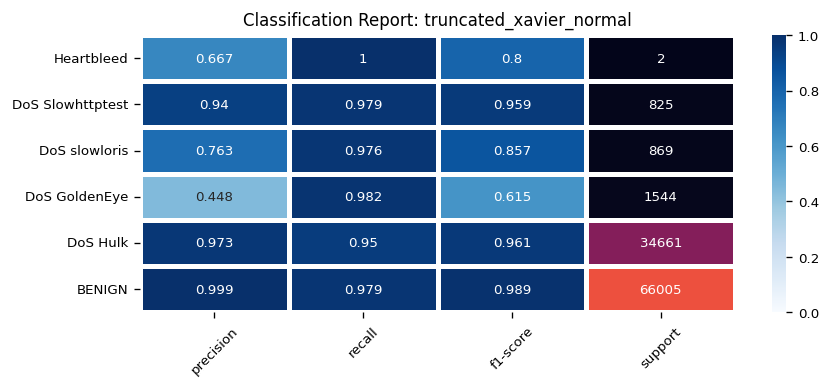

In [96]:
fig, ax = plot_classification_report(y_test,
                    selected_predictions,
                    title=f'Classification Report: {selected_method}',
                    figsize=(8, 3), dpi=FIG_DPI,
                    target_names = class_names)

### Integrated-Gradients Explainability

The validation-loss-selected model is explained at two levels:

1. **Global explanation:** mean absolute attribution across a class-balanced sample of test flows.
2. **Class-specific explanation:** mean absolute attribution among correctly classified test flows for each class.
3. **Local explanation:** signed feature contributions for one selected flow.

A class-balanced explanation sample prevents the benign majority from completely dominating the global attribution summary.

In [70]:
integrated_gradients = IntegratedGradients(selected_model)

rng = np.random.default_rng(SEED)
XAI_SAMPLES_PER_CLASS = 256

balanced_xai_indices = []
for class_index in range(n_classes):
    candidate_indices = np.where(y_test == class_index)[0]
    sample_size = min(
        XAI_SAMPLES_PER_CLASS,
        len(candidate_indices),
    )
    chosen = rng.choice(
        candidate_indices,
        size=sample_size,
        replace=False,
    )
    balanced_xai_indices.extend(chosen.tolist())

balanced_xai_indices = np.array(
    balanced_xai_indices,
    dtype=int,
)

xai_inputs = torch.from_numpy(
    X_test[balanced_xai_indices]
).float().to(device)

with torch.no_grad():
    xai_logits = selected_model(xai_inputs)
    xai_targets = xai_logits.argmax(dim=1)

xai_baselines = torch.zeros_like(xai_inputs)

xai_attributions, convergence_delta = integrated_gradients.attribute(
    xai_inputs,
    baselines=xai_baselines,
    target=xai_targets,
    n_steps=64,
    internal_batch_size=min(max(len(xai_inputs), 2048), 8192),
    return_convergence_delta=True,
)

xai_attributions_np = xai_attributions.detach().cpu().numpy()
convergence_delta_np = convergence_delta.detach().cpu().numpy()

print("Explanation samples:", len(balanced_xai_indices))
print(
    "Mean absolute completeness delta:",
    float(np.mean(np.abs(convergence_delta_np))),
)

Explanation samples: 1282
Mean absolute completeness delta: 0.22740118205547333


,feature,mean_absolute_integrated_gradient
3,DestinationPort,31.200663
4,PSHFlagCount,10.202578
1,BwdPacketLengthStd,9.575494
6,FINFlagCount,4.752613
2,MinPacketLength,4.193055
5,FwdIATTotal,3.483646
0,BwdPackets/s,3.132629
7,FwdPSHFlags,2.930040
8,act_data_pkt_fwd,1.159320


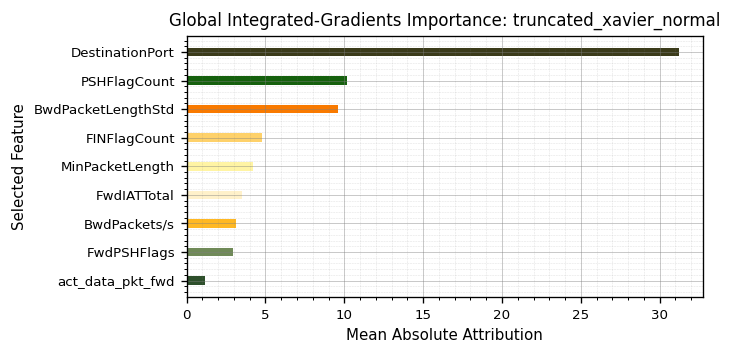

In [73]:
global_attribution = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "mean_absolute_integrated_gradient": np.mean(
        np.abs(xai_attributions_np),
        axis=0,
    ),
}).sort_values(
    "mean_absolute_integrated_gradient",
    ascending=True,
)

display(
    global_attribution.sort_values(
        "mean_absolute_integrated_gradient",
        ascending=False,
    )
)

plt.figure(figsize=(6, 3), dpi=FIG_DPI)
plt.barh(
    global_attribution["feature"],
    global_attribution["mean_absolute_integrated_gradient"],
    color=[
        theme_color(i)
        for i in range(len(global_attribution))
    ],
    height=.3
)
plt.title(
    f"Global Integrated-Gradients Importance: {selected_method}"
)
plt.xlabel("Mean Absolute Attribution")
plt.ylabel("Selected Feature")
finish_plot()

### Class-Specific Global Explanations

For each class, the notebook explains correctly classified test flows and targets that class's logit. This provides a descriptive feature signature for the model's successful decisions.

The rarest classes may contain very few correctly classified test observations, so their attribution estimates must be interpreted cautiously.

In [74]:
class_attribution_rows = []
class_attribution_sample_counts = []

MAX_CLASS_EXPLANATIONS = 256

for class_index, class_name in enumerate(class_names):
    correct_indices = np.where(
        (y_test == class_index)
        & (selected_predictions == class_index)
    )[0]

    if len(correct_indices) == 0:
        class_attribution_sample_counts.append({
            "class_name": class_name,
            "correct_explanation_samples": 0,
        })
        for feature in SELECTED_FEATURES:
            class_attribution_rows.append({
                "class_name": class_name,
                "feature": feature,
                "mean_absolute_attribution": np.nan,
            })
        continue

    sample_size = min(
        MAX_CLASS_EXPLANATIONS,
        len(correct_indices),
    )
    chosen_indices = rng.choice(
        correct_indices,
        size=sample_size,
        replace=False,
    )

    inputs = torch.from_numpy(
        X_test[chosen_indices]
    ).float().to(device)

    targets = torch.full(
        (sample_size,),
        class_index,
        dtype=torch.long,
        device=device,
    )

    attributions = integrated_gradients.attribute(
        inputs,
        baselines=torch.zeros_like(inputs),
        target=targets,
        n_steps=64,
        internal_batch_size=min(max(sample_size, 1024), 4096),
    )

    mean_abs = (
        attributions
        .detach()
        .cpu()
        .numpy()
    )
    mean_abs = np.mean(np.abs(mean_abs), axis=0)

    class_attribution_sample_counts.append({
        "class_name": class_name,
        "correct_explanation_samples": sample_size,
    })
    for feature, value in zip(
        SELECTED_FEATURES,
        mean_abs,
    ):
        class_attribution_rows.append({
            "class_name": class_name,
            "feature": feature,
            "mean_absolute_attribution": value,
        })

class_attribution_df = pd.DataFrame(
    class_attribution_rows
)
class_attribution_counts_df = pd.DataFrame(
    class_attribution_sample_counts
)

display(class_attribution_counts_df)

,class_name,correct_explanation_samples
0,BENIGN,256
1,DoS GoldenEye,256
2,DoS Hulk,256
3,DoS Slowhttptest,256
4,DoS slowloris,256
5,Heartbleed,2


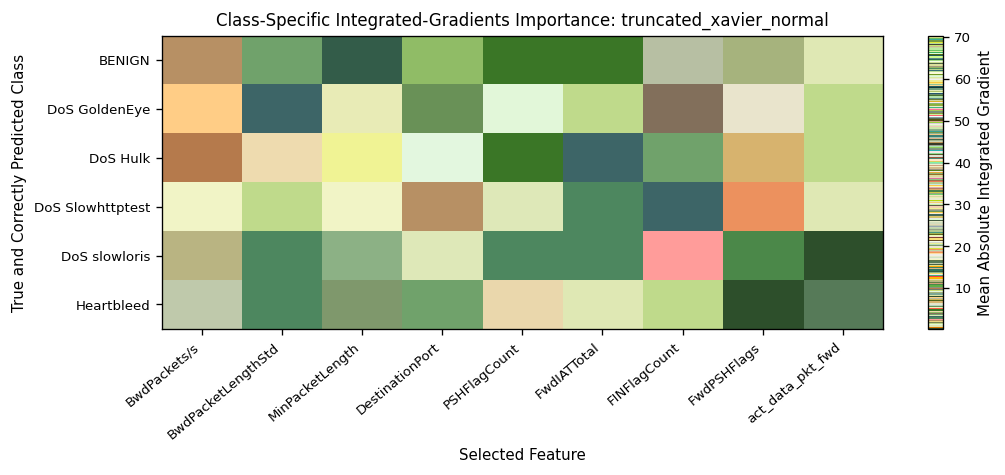

In [75]:
class_attribution_heatmap = class_attribution_df.pivot(
    index="class_name",
    columns="feature",
    values="mean_absolute_attribution",
).reindex(class_names)

plt.figure(figsize=(9, 4), dpi=FIG_DPI)
image = plt.imshow(
    class_attribution_heatmap.values,
    aspect="auto",
    cmap=THEME_CMAP,
)
plt.colorbar(image, label="Mean Absolute Integrated Gradient")
plt.xticks(
    np.arange(len(SELECTED_FEATURES)),
    SELECTED_FEATURES,
    rotation=40,
    ha="right",
)
plt.yticks(
    np.arange(n_classes),
    class_names,
)
plt.title(
    f"Class-Specific Integrated-Gradients Importance: {selected_method}"
)
plt.xlabel("Selected Feature")
plt.ylabel("True and Correctly Predicted Class")
plt.tight_layout()
plt.show()

### Local Explanation for One Network Flow

Set `LOCAL_CLASS_NAME` to the traffic class that should be explained.

Selection logic:

1. prefer a correctly classified test flow from that class;
2. otherwise select the test flow with the highest predicted probability for that class.

The output table includes:

- original feature value;
- standardized feature value;
- signed Integrated-Gradients attribution;
- absolute attribution;
- whether the feature supports or opposes the explained class relative to the training-mean baseline.

In [76]:
LOCAL_CLASS_NAME = (
    "DoS Hulk"
    if "DoS Hulk" in class_names
    else class_names[0]
)

local_class_index = int(
    np.where(class_names == LOCAL_CLASS_NAME)[0][0]
)

correct_local_candidates = np.where(
    (y_test == local_class_index)
    & (selected_predictions == local_class_index)
)[0]

if len(correct_local_candidates) > 0:
    local_index = int(correct_local_candidates[0])
    local_selection_note = "correctly classified test flow"
else:
    class_probabilities = probability_store[
        selected_method
    ][:, local_class_index]
    local_index = int(np.argmax(class_probabilities))
    local_selection_note = (
        "highest predicted probability for the requested class"
    )

local_input = torch.from_numpy(
    X_test[local_index : local_index + 1]
).float().to(device)

local_target = torch.tensor(
    [local_class_index],
    dtype=torch.long,
    device=device,
)

local_attribution, local_delta = integrated_gradients.attribute(
    local_input,
    baselines=torch.zeros_like(local_input),
    target=local_target,
    n_steps=128,
    return_convergence_delta=True,
)

local_attribution_np = (
    local_attribution
    .detach()
    .cpu()
    .numpy()[0]
)

fitted_scaler = (
    preprocessor
    .named_transformers_["standardize"]
    .named_steps["scaler"]
)
local_original_values = fitted_scaler.inverse_transform(
    X_test[local_index : local_index + 1]
)[0]

local_probabilities = probability_store[
    selected_method
][local_index]

local_explanation_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "original_value": local_original_values,
    "standardized_value": X_test[local_index],
    "integrated_gradient": local_attribution_np,
    "absolute_attribution": np.abs(local_attribution_np),
    "direction": np.where(
        local_attribution_np >= 0,
        "supports explained class",
        "opposes explained class",
    ),
}).sort_values(
    "absolute_attribution",
    ascending=False,
)

print("Selection:", local_selection_note)
print(
    "True class:",
    class_names[y_test[local_index]],
)
print(
    "Predicted class:",
    class_names[selected_predictions[local_index]],
)
print(
    f"Probability assigned to {LOCAL_CLASS_NAME}: "
    f"{local_probabilities[local_class_index]:.4f}"
)
print(
    "Integrated-Gradients completeness delta:",
    float(local_delta.detach().cpu().item()),
)

display(local_explanation_df)

Selection: correctly classified test flow
True class: DoS Hulk
Predicted class: DoS Hulk
Probability assigned to DoS Hulk: 0.9348
Integrated-Gradients completeness delta: 0.4097728729248047


,feature,original_value,standardized_value,integrated_gradient,absolute_attribution,direction
3,DestinationPort,8.000000e+01,-0.356682,51.575081,51.575081,supports explained class
4,PSHFlagCount,0.000000e+00,-0.490313,-17.083166,17.083166,opposes explained class
6,FINFlagCount,-7.450581e-09,-0.328195,-10.016969,10.016969,opposes explained class
2,MinPacketLength,-9.536743e-07,-0.495034,8.201447,8.201447,supports explained class
0,BwdPackets/s,0.000000e+00,-0.132709,-8.071944,8.071944,opposes explained class
7,FwdPSHFlags,0.000000e+00,-0.210585,-7.020656,7.020656,opposes explained class
5,FwdIATTotal,9.920000e+02,-0.648831,3.939144,3.939144,supports explained class
8,act_data_pkt_fwd,0.000000e+00,-0.008658,2.736610,2.736610,supports explained class
1,BwdPacketLengthStd,0.000000e+00,-0.600106,-0.839677,0.839677,opposes explained class


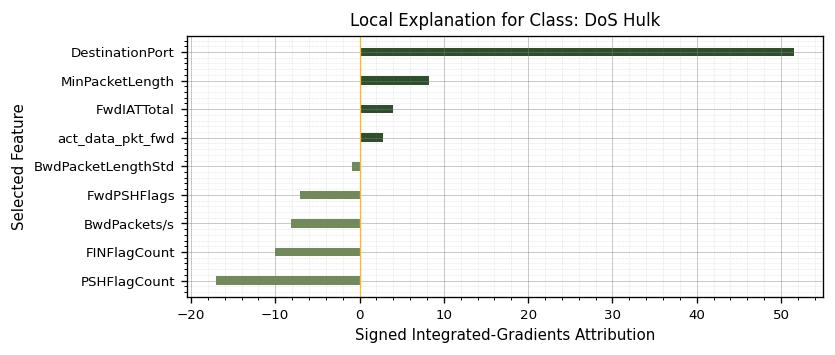

In [78]:
local_plot_df = local_explanation_df.sort_values(
    "integrated_gradient",
    ascending=True,
)

local_colors = [
    theme_color(0) if value >= 0 else theme_color(1)
    for value in local_plot_df["integrated_gradient"]
]

plt.figure(figsize=(7, 3), dpi=FIG_DPI)
plt.barh(
    local_plot_df["feature"],
    local_plot_df["integrated_gradient"],
    color=local_colors,
    height=.3
)
plt.axvline(
    0,
    linewidth=0.8,
    color=theme_color(2),
)
plt.title(
    f"Local Explanation for Class: {LOCAL_CLASS_NAME}"
)
plt.xlabel(
    "Signed Integrated-Gradients Attribution"
)
plt.ylabel("Selected Feature")
finish_plot()

### Explainability Interpretation Guide for DoS-Related Traffic

The attribution plots should be interpreted together with domain knowledge:

- packet-rate features can reflect high-volume flooding behaviour;
- packet-length variation can distinguish traffic-generation patterns;
- inter-arrival-time features can reflect slow or bursty traffic;
- TCP flag features may characterize connection-management behaviour;
- destination ports can reveal service-specific patterns learned from the dataset.

However, a large attribution means that the **model relied on the feature for that prediction**. It does not prove that the feature alone defines an attack, and it may expose dataset-specific correlations. Explanations for Heartbleed are especially uncertain because very few examples are available.

### Save Reproducibility Artifacts

The notebook saves:

- data preprocessor;
- label encoder;
- selected feature names;
- class weights;
- experiment configuration;
- initialization diagnostics;
- training histories;
- test metrics and confidence intervals;
- per-class metrics;
- Integrated-Gradients summaries;
- the validation-loss-selected model's best checkpoint.

In [79]:
joblib.dump(
    {
        "preprocessor": preprocessor,
        "label_encoder": label_encoder,
        "selected_features": SELECTED_FEATURES,
    },
    RESULTS_DIR / "preprocessing_bundle.joblib",
)

experiment_metadata = {
    "seed": SEED,
    "run_mode": RUN_MODE,
    "dataset_path": str(DATA_PATH),
    "selected_features": SELECTED_FEATURES,
    "class_names": class_names.tolist(),
    "class_weights": class_weights_np.tolist(),
    "initialization_methods": INIT_METHODS,
    "hidden_dims": list(HIDDEN_DIMS),
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "validation_selected_method": selected_method,
    "accuracy_ci_method": "95% Wilson score interval",
    "explainability_method": "Integrated Gradients",
}

with open(
    RESULTS_DIR / "experiment_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_metadata,
        file,
        indent=2,
    )

initialization_diagnostics.to_csv(
    RESULTS_DIR / "initialization_diagnostics.csv",
    index=False,
)
global_attribution.to_csv(
    RESULTS_DIR / "global_integrated_gradients.csv",
    index=False,
)
class_attribution_df.to_csv(
    RESULTS_DIR / "class_specific_integrated_gradients.csv",
    index=False,
)
local_explanation_df.to_csv(
    RESULTS_DIR / "local_integrated_gradients.csv",
    index=False,
)
mcnemar_summary.to_csv(
    RESULTS_DIR / "exact_mcnemar_test.csv",
    index=False,
)

print(f"Artifacts saved under: {RESULTS_DIR.resolve()}")
print(
    "Validation-selected checkpoint:",
    selected_summary["checkpoint_path"],
)

Artifacts saved under: C:\Users\crisp\Documents\PENDING PROJECTS\DOS\results_weight_initialization_ddos
Validation-selected checkpoint: checkpoints_weight_initialization_ddos\truncated_xavier_normal_best.pt
